<a href="https://colab.research.google.com/github/Heitorcp/Heitorcp/blob/main/ZINB_lgbm.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#ZINB Objective Functions for Gradient Boosting

Zero-inflated negative binomial (ZINB) regression is a statistical method used to model count data with an excess of zeros. This is often observed in real-world scenarios,such as inventory forecasts in which the data is always count, and often zero-inflated.

Understanding ZINB:

ZINB models address two underlying processes contributing to the excess zeros:

Count Process: This is modeled using a negative binomial distribution, which accounts for overdispersion, a situation where the variance is greater than the mean, commonly found in count data, this is something poisson can't achieve....

Zero-Inflation Process: This is modeled using a binary process, usually a bernoulli process.... to estimate the probability of an observation being a structural zero (a zero that is not part of the count process). This separate zero inflation component may be helpful in our context as opposed to a compound/mixture distribution like Tweedie.

Advantages Over Tweedie:
* Directly Model Counts
* (Possibly) Handles Over Dispersion Better

Cons:
* Less Flexible, definitely a more niche use case than tweedie.

In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from lightgbm import LGBMRegressor



from scipy.optimize import minimize
from scipy.special import gammaln,expit
import numpy as np

def negbinom_nll(r, y, mu):
    """Negative log-likelihood for the Negative Binomial distribution."""

    pi = np.mean(y == 0)
    zero_component = np.sum(y == 0) * np.log(pi)

    # Non-zero observations: standard Negative Binomial log-likelihood
    non_zero_log = np.sum((y > 0) * (
        gammaln(y + r)
        - gammaln(r)
        - gammaln(y + 1)
        + r * np.log(r)
        + y * np.log(mu)
        - (r + y) * np.log(r + mu)
    ))

    # Total NLL is the sum of both components
    nll = -(zero_component + non_zero_log)
    return nll  # Sum of NLLs across all observations

def estimate_r_mle(y, mu):
    """Estimate r using MLE (Maximize the log-likelihood)."""
    result = minimize(lambda r: negbinom_nll(r, y, mu), x0=[1], bounds=[(0.001, 1000)])
    return result.x[0] # Return the estimated r

def create_neg_binom_objective(train):
    mus = np.full(train.shape[0],train['y'].mean())
    optimized_r = estimate_r_mle(train['y'],mus)

    def negbinom_objective(y_true, y_pred):
        r = optimized_r # Dispersion parameter (can tune manually or estimate)

        # Predicted mean from log-link
        mu = np.exp(np.clip(y_pred, 0, 1000))

        # Estimate a zero-inflation probability as a function of mu
        # Example: small mu → high zero inflation
        pi = expit(-mu + 1.5)  # tune 1.5 as a pivot point if desired

        # Base NB gradient and hessian
        grad = (mu - y_true) / (mu + r) * mu
        hess = ((r + y_true) * mu**2 + (y_true - mu) * mu) / (mu + r)**2

        # Apply zero-inflation weighting only to zero observations
        is_zero = (y_true == 0)
        grad[is_zero] *= (1 - pi[is_zero])
        hess[is_zero] *= (1 - pi[is_zero])

        return grad, hess

    return negbinom_objective

# Zero Damping Parameter: Changing the constant "C" to arrive at pi

* pi acts as a damper to the gradient/hessian when the actual target value is zero and the model prediction is low

* in this case, adding zero to expit(-mu) would result in a larger complement which would mean less gradient damping. This could be a tuneable hyper-parameter

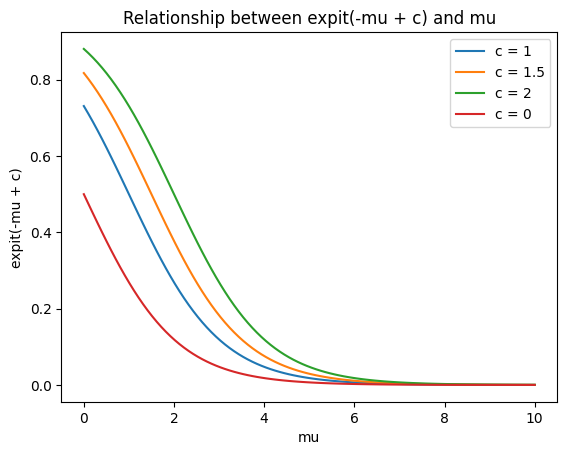

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import expit

# Generate a range of mu values
mu = np.linspace(0, 10, 100)

# Calculate expit(-mu + c) for different c values
c_values = [1, 1.5, 2, 0]
for c in c_values:
    y = expit(-mu + c)
    plt.plot(mu, y, label=f'c = {c}')

# Set plot labels and title
plt.xlabel('mu')
plt.ylabel('expit(-mu + c)')
plt.title('Relationship between expit(-mu + c) and mu')

# Add legend
plt.legend()

# Show the plot
plt.show()

In [ ]:

# 1. Generate over-dispersed, zero-inflated count-like data
np.random.seed(42)
n_samples = 30000
n_features = 5

X = np.random.normal(0, 1, size=(n_samples, n_features))
lin_pred = X @ np.random.uniform(-1, 1, size=n_features)

# Mean parameter for Negative Binomial-like generation
mu = np.exp(lin_pred * 5)

# Introduce overdispersion using Negative Binomial distribution
# Adjust 'n' (size parameter) for desired level of overdispersion
y_continuous = np.random.negative_binomial(n=5, p=1 / (1 + mu / 5), size=n_samples)

# Inject structural zeros
zero_mask = np.random.binomial(1, 0.7, size=n_samples)

# Ensure y is non-negative and integer-valued
y = np.clip(y_continuous * (1 - zero_mask), a_min=0, a_max=None).astype(int)


In [ ]:

# Convert to float32 to match LightGBM's expectations
y = y.astype(np.float32)

# 2. Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# 3. LGBMRegressor with Tweedie objective
model_tweedie = LGBMRegressor(
    objective='tweedie',
    tweedie_variance_power=1.5,  # between 1 and 2 for count-like
    verbosity=-1
)

model_tweedie.fit(X_train, y_train)

# 4. LGBMRegressor with RMSE objective
model_poisson = LGBMRegressor(
    objective='poisson',
    verbosity=-1
)

model_poisson.fit(X_train, y_train)


#create negative binom obj
negbinom_objective = create_neg_binom_objective(pd.DataFrame({'y':y_train}))

# 5. LGBMRegressor with Neg Binom Objective
model_negbin = LGBMRegressor(
    objective=negbinom_objective,
    verbosity=-1
)

model_negbin.fit(X_train, y_train)

# 5. Predictions and evaluation
preds_tweedie = model_tweedie.predict(X_test)
preds_rmse = model_poisson.predict(X_test)
preds_negbin = model_negbin.predict(X_test)

rmse_tweedie = np.sqrt(mean_squared_error(y_test, preds_tweedie))
rmse_rmse = np.sqrt(mean_squared_error(y_test, preds_rmse))
rmse_negbin = np.sqrt(mean_squared_error(y_test, preds_negbin))

print(f"RMSE (Tweedie): {rmse_tweedie}")
print(f"RMSE (Poisson objective): {rmse_rmse}") # poisson does very bad as it doesn't account for variance != mean
print(f"RMSE (Neg Binom objective): {rmse_negbin}")

/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


RMSE (Tweedie): 2235786.4007404316
RMSE (RMSE objective): 2.1069436531175286e+17
RMSE (Neg Binom objective): 1724239.2272221334


/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


<Axes: title={'center': 'RMSE Scores'}>

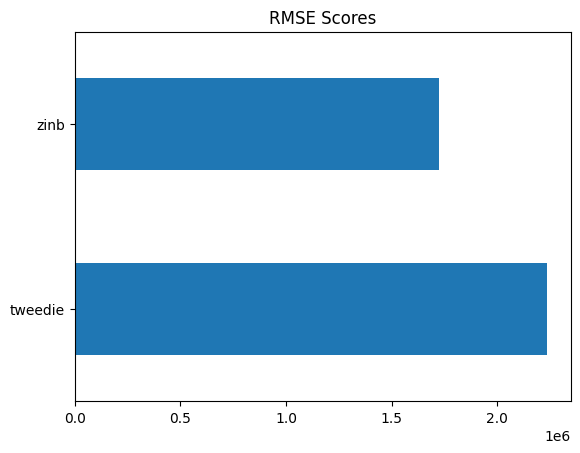

In [ ]:
scores = {'tweedie':rmse_tweedie,'zinb':rmse_negbin} #results against tweedie. If we find a better way to optimize this obj it's a promising alternative!

pd.Series(scores).plot.barh(title='RMSE Scores')